# Image Baseline — Fraud Detection
ResNet-18 fine-tuned for binary document/image fraud classification.

### Pipeline
1. Imports & reproducibility  
2. Paths & config  
3. Load & validate splits  
4. Visualise class balance  
5. Build dataloaders  
6. Stage 1 — frozen backbone (head warmup)  
7. Stage 2 — full fine-tuning  
8. Training curves  
9. Threshold tuning on validation set  
10. Test evaluation + confusion matrix + ROC curve  
11. Multi-seed robustness  
12. Subgroup analysis  
13. GradCAM sanity check  
14. Final summary table

In [5]:
import sys
sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve, auc

# Show plots inline
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from image_baseline_test import (
    load_image_splits, print_split_summary, build_dataloaders,
    build_model, unfreeze_backbone, make_loss_fn,
    fit_model, run_test_evaluation,
    predict_probs, compute_metrics, tune_threshold, evaluate,
    subgroup_metrics, build_val_transform,
    GradCAM,
)

In [6]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.11.0+cpu


In [7]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "notebook" / "results" / "image_baseline"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "image_train_group_test.csv"
VAL_CSV   = DATA_DIR / "image_val_group_test.csv"
TEST_CSV  = DATA_DIR / "image_test_group_test.csv"

BATCH_SIZE  = 32
NUM_WORKERS = 0

print("Data dir  :", DATA_DIR)
print("Results   :", RESULTS_DIR)

Data dir  : C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed
Results   : C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\image_baseline


In [8]:
# Make sure this imports from the NEW file, not image_baseline_test
from image_baseline_utils import build_model, predict_probs, compute_metrics

# Must use dropout=0.3 to match the Sequential head that was saved
model = build_model(pretrained=False, freeze_backbone=False, dropout=0.3).to(device)
model.load_state_dict(torch.load(RESULTS_DIR / "stage2_best.pt", map_location=device))
model.eval()

history        = pd.read_csv(RESULTS_DIR / "training_history.csv")
history_s1     = history[history["epoch"] <= 5].copy()
history_s2     = history[history["epoch"] > 5].copy()
best_threshold = 0.45

y_true_test, y_prob_test = predict_probs(model, test_loader, device)
test_pred_df = splits.test_df.reset_index(drop=True).copy()
test_pred_df["y_true"] = y_true_test
test_pred_df["y_prob"] = y_prob_test
test_pred_df["y_pred"] = (test_pred_df["y_prob"] >= best_threshold).astype(int)

test_metrics = compute_metrics(y_true_test, y_prob_test, threshold=best_threshold)
print(f"Model loaded | threshold={best_threshold} | ready to continue")

TypeError: build_model() got an unexpected keyword argument 'dropout'

In [9]:
import image_baseline_utils
print(image_baseline_utils.__file__)

C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\image_baseline_utils.py


## 1 · Load & validate splits

In [11]:
splits = load_image_splits(
    train_csv=TRAIN_CSV,
    val_csv=VAL_CSV,
    test_csv=TEST_CSV,
)
print_split_summary(splits.train_df, splits.val_df, splits.test_df)


TRAIN
Rows: 7182
Groups: 953
image_class
forged       3731
bona_fide    3451
Name: count, dtype: int64
image_class
forged       51.95
bona_fide    48.05
Name: proportion, dtype: float64

VAL
Rows: 1508
Groups: 204
image_class
forged       765
bona_fide    743
Name: count, dtype: int64
image_class
forged       50.73
bona_fide    49.27
Name: proportion, dtype: float64

TEST
Rows: 1474
Groups: 205
image_class
bona_fide    739
forged       735
Name: count, dtype: int64
image_class
bona_fide    50.14
forged       49.86
Name: proportion, dtype: float64

GROUP OVERLAP
  train_val_overlap: 0
  train_test_overlap: 0
  val_test_overlap: 0


## 2 · Visualise class balance

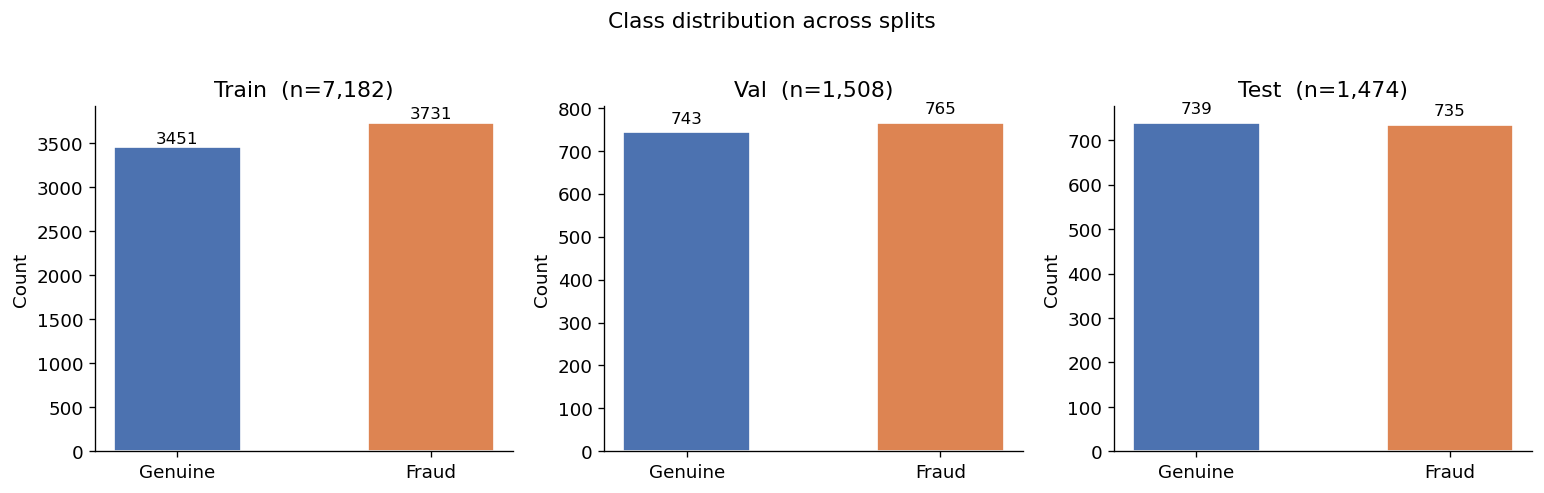

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colours = ["#4C72B0", "#DD8452"]

for ax, (name, df) in zip(axes, [("Train", splits.train_df),
                                   ("Val",   splits.val_df),
                                   ("Test",  splits.test_df)]):
    counts = df["label_int"].value_counts().sort_index()
    bars = ax.bar(["Genuine", "Fraud"], counts.values, color=colours, edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
                str(val), ha="center", va="bottom", fontsize=10)
    ax.set_title(f"{name}  (n={len(df):,})")
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Class distribution across splits", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 3 · Build dataloaders
Training uses an augmented transform (random crop, flips, colour jitter, random erasing). Val/test use a deterministic centre-crop — no data leakage.

In [13]:
train_loader, val_loader, test_loader = build_dataloaders(
    splits=splits,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 225
Val batches   : 48
Test batches  : 47


## 4 · Stage 1 — frozen backbone (head warmup)
Only the Dropout + Linear head is trained. The pretrained backbone weights are held fixed.  
This prevents the large random gradients from a fresh head destroying the ImageNet features.

In [14]:
STAGE1_EPOCHS   = 5
STAGE1_LR       = 1e-3
STAGE1_PATIENCE = 5

model   = build_model(pretrained=True, freeze_backbone=True, dropout=0.3).to(device)
loss_fn = make_loss_fn(splits.train_df, device=device)

optimizer_s1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR, weight_decay=1e-4,
)

model, history_s1 = fit_model(
    model=model, train_loader=train_loader, val_loader=val_loader,
    loss_fn=loss_fn, optimizer=optimizer_s1, device=device,
    epochs=STAGE1_EPOCHS, threshold=0.5,
    early_stopping_patience=STAGE1_PATIENCE,
    monitor_metric="val_roc_auc",
    model_save_path=RESULTS_DIR / "stage1_best.pt",
)

print("\nStage 1 history:")
display(history_s1.round(4))

  pos_weight = 0.925  (n_neg=3451, n_pos=3731)


KeyboardInterrupt: 

## 5 · Stage 2 — full fine-tuning (backbone unfrozen)
Differential learning rates: backbone gets 10× lower LR than the head to avoid catastrophic forgetting.  
CosineAnnealingLR smoothly decays the LR to near-zero over the training budget.

In [ ]:
STAGE2_EPOCHS   = 20
BACKBONE_LR     = 1e-5
HEAD_LR         = 1e-4
STAGE2_PATIENCE = 6

unfreeze_backbone(model)

backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
head_params     = list(model.fc.parameters())

optimizer_s2 = torch.optim.Adam(
    [{"params": backbone_params, "lr": BACKBONE_LR},
     {"params": head_params,     "lr": HEAD_LR}],
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_s2, T_max=STAGE2_EPOCHS, eta_min=1e-7,
)

model, history_s2 = fit_model(
    model=model, train_loader=train_loader, val_loader=val_loader,
    loss_fn=loss_fn, optimizer=optimizer_s2, device=device,
    epochs=STAGE2_EPOCHS, threshold=0.5,
    early_stopping_patience=STAGE2_PATIENCE,
    monitor_metric="val_roc_auc",
    scheduler=scheduler,
    model_save_path=RESULTS_DIR / "stage2_best.pt",
)

print("\nStage 2 history:")
display(history_s2.round(4))

Backbone unfrozen — all parameters are now trainable.
Epoch 01 | lr=1.00e-05 | train_loss=0.2737 | val_loss=0.2212 | val_f1=0.8923 | val_roc_auc=0.9627
  ✓ Saved best model (epoch 1, val_roc_auc=0.9627)
Epoch 02 | lr=9.94e-06 | train_loss=0.2283 | val_loss=0.2123 | val_f1=0.9074 | val_roc_auc=0.9645
  ✓ Saved best model (epoch 2, val_roc_auc=0.9645)
Epoch 03 | lr=9.76e-06 | train_loss=0.2177 | val_loss=0.1973 | val_f1=0.9099 | val_roc_auc=0.9656
  ✓ Saved best model (epoch 3, val_roc_auc=0.9656)
Epoch 04 | lr=9.46e-06 | train_loss=0.2046 | val_loss=0.1960 | val_f1=0.9013 | val_roc_auc=0.9659
  ✓ Saved best model (epoch 4, val_roc_auc=0.9659)
Epoch 05 | lr=9.05e-06 | train_loss=0.1953 | val_loss=0.1908 | val_f1=0.9132 | val_roc_auc=0.9670
  ✓ Saved best model (epoch 5, val_roc_auc=0.9670)
Epoch 06 | lr=8.55e-06 | train_loss=0.1912 | val_loss=0.1911 | val_f1=0.9058 | val_roc_auc=0.9675
  ✓ Saved best model (epoch 6, val_roc_auc=0.9675)
Epoch 07 | lr=7.96e-06 | train_loss=0.1878 | val_los

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.2737,0.2212,0.8893,0.8804,0.9046,0.8923,0.9627
1,2,0.0,0.2283,0.2123,0.9019,0.8703,0.9477,0.9074,0.9645
2,3,0.0,0.2177,0.1973,0.9052,0.8783,0.9438,0.9099,0.9656
3,4,0.0,0.2046,0.1960,0.8979,0.8843,0.9190,0.9013,0.9659
4,5,0.0,0.1953,0.1908,0.9085,0.8800,0.9490,0.9132,0.9670
5,6,0.0,0.1912,0.1911,0.9025,0.8882,0.9242,0.9058,0.9675
6,7,0.0,0.1878,0.1924,0.8985,0.8893,0.9137,0.9014,0.9680
7,8,0.0,0.1856,0.1930,0.8992,0.8885,0.9163,0.9022,0.9680
8,9,0.0,0.1828,0.1867,0.9098,0.8831,0.9477,0.9142,0.9680
9,10,0.0,0.1832,0.1864,0.9105,0.8823,0.9503,0.9150,0.9684


In [17]:
import torch, pandas as pd
from pathlib import Path

# Save model weights
torch.save(model.state_dict(), RESULTS_DIR / "final_model.pt")

# Save training history and threshold
history_s2.to_csv(RESULTS_DIR / "training_history.csv", index=False)
pd.Series({"best_threshold": best_threshold}).to_csv(RESULTS_DIR / "best_threshold.csv")

print("Saved to:", RESULTS_DIR)

NameError: name 'history_s2' is not defined

## 6 · Training curves

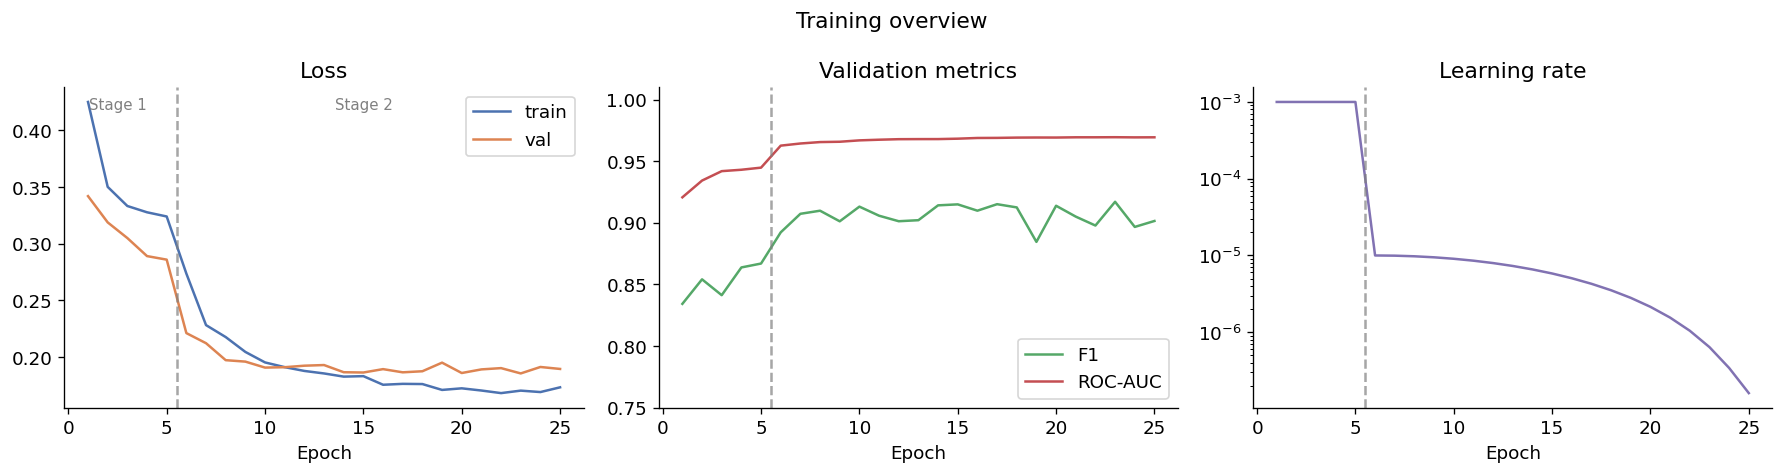

In [ ]:
history = pd.concat([history_s1, history_s2], ignore_index=True)
history["epoch_global"] = range(1, len(history) + 1)
history.to_csv(RESULTS_DIR / "training_history.csv", index=False)

n_s1 = len(history_s1)
ep   = history["epoch_global"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Loss —
axes[0].plot(ep, history["train_loss"], label="train", color="#4C72B0")
axes[0].plot(ep, history["val_loss"],   label="val",   color="#DD8452")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

# — Val metrics —
axes[1].plot(ep, history["val_f1"],      label="F1",      color="#55A868")
axes[1].plot(ep, history["val_roc_auc"], label="ROC-AUC", color="#C44E52")
axes[1].set_ylim(0.75, 1.01)
axes[1].set_title("Validation metrics"); axes[1].set_xlabel("Epoch"); axes[1].legend()

# — Learning rate —
axes[2].plot(ep, history["lr"], color="#8172B2")
axes[2].set_title("Learning rate"); axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log")

for ax in axes:
    ax.axvline(x=n_s1 + 0.5, color="gray", linestyle="--", alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].text(n_s1 / 2, axes[0].get_ylim()[1] * 0.98, "Stage 1",
             ha="center", va="top", fontsize=9, color="gray")
axes[0].text(n_s1 + (len(ep) - n_s1) / 2, axes[0].get_ylim()[1] * 0.98, "Stage 2",
             ha="center", va="top", fontsize=9, color="gray")

fig.suptitle("Training overview", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 · Threshold tuning on the validation set
The default threshold of 0.5 is rarely optimal for fraud tasks. We sweep thresholds on the **validation** set and pick the one that maximises F1. The chosen threshold is then fixed and applied to the test set exactly once.


Best threshold (f1): 0.45
 threshold  accuracy  precision   recall       f1  roc_auc
      0.10  0.901194   0.836980 1.000000 0.911257 0.969563
      0.15  0.902520   0.839560 0.998693 0.912239 0.969563
      0.20  0.903183   0.841235 0.997386 0.912679 0.969563
      0.25  0.903183   0.844271 0.992157 0.912260 0.969563
      0.30  0.907825   0.851685 0.990850 0.916012 0.969563
      0.35  0.912467   0.863375 0.983007 0.919315 0.969563
      0.40  0.910477   0.866279 0.973856 0.916923 0.969563
      0.45  0.915119   0.880526 0.963399 0.920100 0.969563
      0.50  0.913130   0.888480 0.947712 0.917141 0.969563
      0.55  0.895889   0.895833 0.899346 0.897586 0.969563
      0.60  0.880637   0.909091 0.849673 0.878378 0.969563
      0.65  0.860743   0.922374 0.792157 0.852321 0.969563
      0.70  0.838196   0.939292 0.728105 0.820324 0.969563
      0.75  0.813660   0.953184 0.665359 0.783680 0.969563
      0.80  0.793103   0.980892 0.603922 0.747573 0.969563
      0.85  0.781830   0.9909

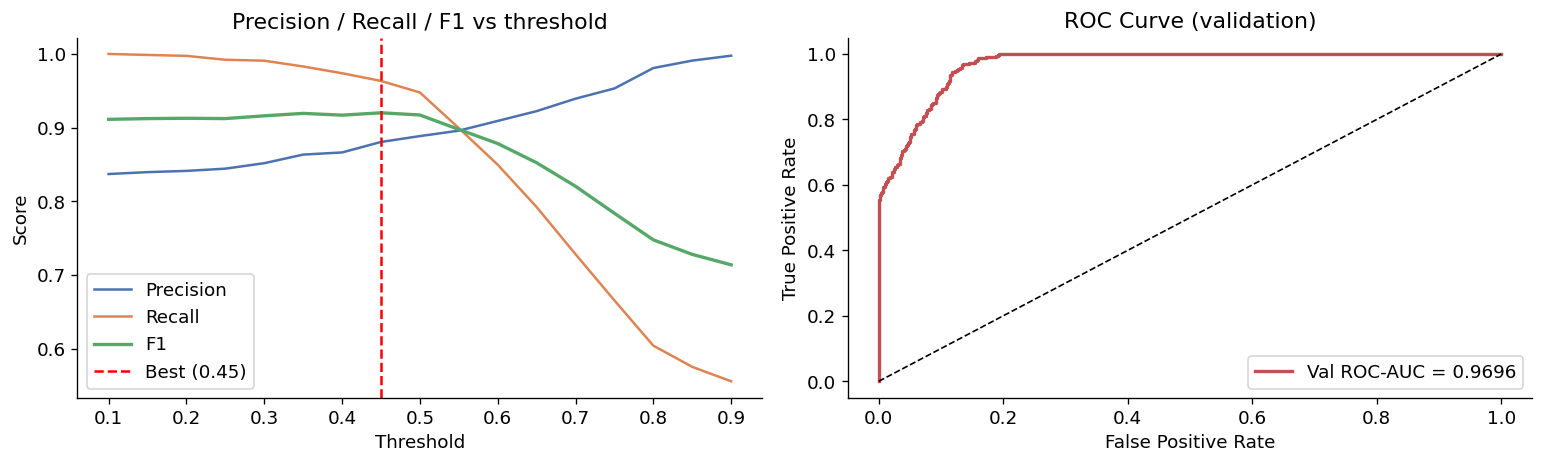


Selected threshold: 0.45


In [ ]:
val_y_true, val_y_prob = predict_probs(model, val_loader, device)
best_threshold, sweep_df = tune_threshold(val_y_true, val_y_prob, metric="f1")
sweep_df.to_csv(RESULTS_DIR / "threshold_sweep.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Precision / Recall / F1 vs threshold
axes[0].plot(sweep_df["threshold"], sweep_df["precision"], label="Precision", color="#4C72B0")
axes[0].plot(sweep_df["threshold"], sweep_df["recall"],    label="Recall",    color="#DD8452")
axes[0].plot(sweep_df["threshold"], sweep_df["f1"],        label="F1",        color="#55A868", linewidth=2)
axes[0].axvline(x=best_threshold, color="red", linestyle="--", label=f"Best ({best_threshold:.2f})")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs threshold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

# ROC curve
fpr, tpr, _ = roc_curve(val_y_true, val_y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#C44E52", lw=2, label=f"Val ROC-AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (validation)")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "threshold_and_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSelected threshold: {best_threshold:.2f}")

## 8 · Test evaluation
The test set is evaluated **once**, using the threshold chosen on the validation set.

In [ ]:
test_metrics = run_test_evaluation(
    model=model, test_loader=test_loader,
    loss_fn=loss_fn, device=device, threshold=best_threshold,
)

# Save predictions
y_true_test, y_prob_test = predict_probs(model, test_loader, device)
test_pred_df = splits.test_df.reset_index(drop=True).copy()
test_pred_df["y_true"] = y_true_test
test_pred_df["y_prob"] = y_prob_test
test_pred_df["y_pred"] = (test_pred_df["y_prob"] >= best_threshold).astype(int)
test_pred_df.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)


── TEST METRICS ──────────────────────────
  loss: 0.1665
  accuracy: 0.9179
  precision: 0.8857
  recall: 0.9592
  f1: 0.9210
  roc_auc: 0.9746
  confusion_matrix:
[[648  91]
 [ 30 705]]
──────────────────────────────────────────


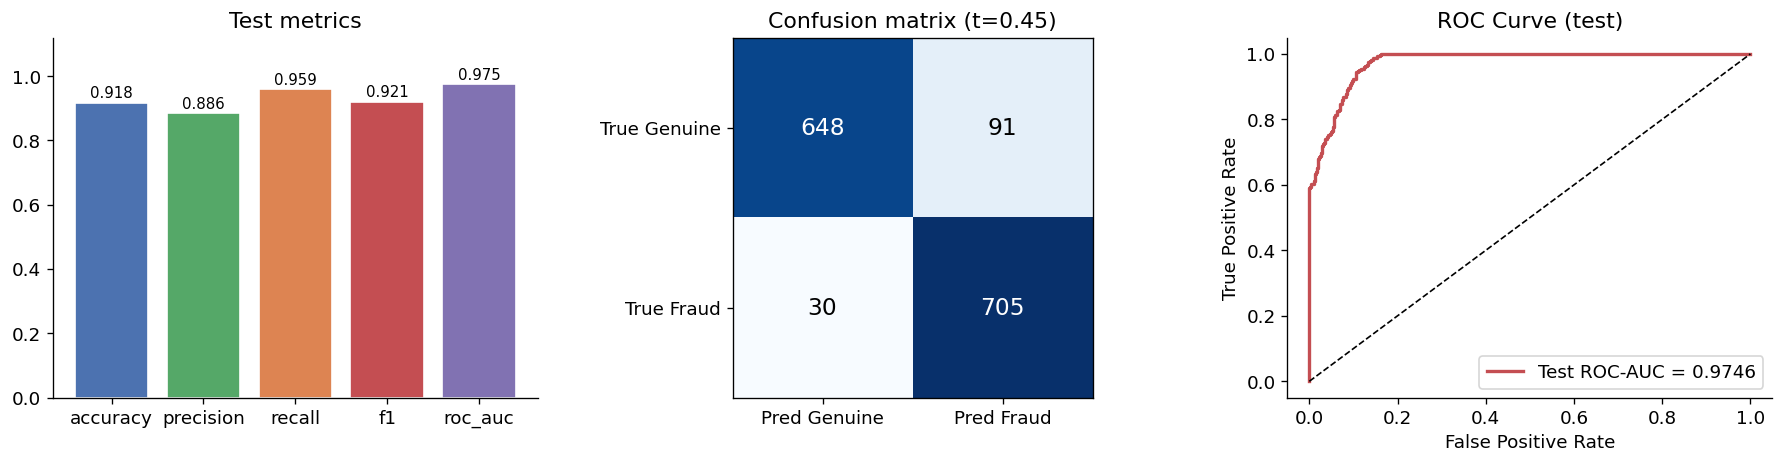

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Metrics bar chart —
metric_keys  = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_vals  = [test_metrics[k] for k in metric_keys]
bar_colours  = ["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8172B2"]
bars = axes[0].bar(metric_keys, metric_vals, color=bar_colours, edgecolor="white")
for bar, val in zip(bars, metric_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, 1.12); axes[0].set_title("Test metrics")
axes[0].spines[["top", "right"]].set_visible(False)

# — Confusion matrix —
cm = np.array(test_metrics["confusion_matrix"])
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Pred Genuine", "Pred Fraud"])
axes[1].set_yticklabels(["True Genuine", "True Fraud"])
axes[1].set_title(f"Confusion matrix (t={best_threshold:.2f})")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                     fontsize=14, color="white" if cm[i, j] > cm.max() / 2 else "black")

# — Test ROC curve —
fpr_t, tpr_t, _ = roc_curve(y_true_test, y_prob_test)
roc_auc_t = sk_auc(fpr_t, tpr_t)
axes[2].plot(fpr_t, tpr_t, color="#C44E52", lw=2, label=f"Test ROC-AUC = {roc_auc_t:.4f}")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve (test)")
axes[2].legend(); axes[2].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "test_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

### Score distribution
This shows how well-separated the model's probability scores are for genuine vs fraud. A clean bimodal split = confident predictions. Overlap in the middle = uncertainty around the decision boundary.

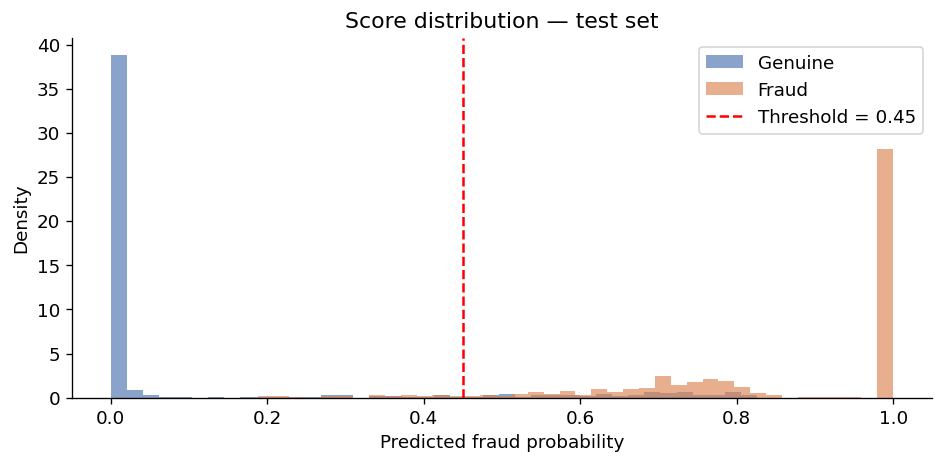

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob_test[y_true_test == 0], bins=40, alpha=0.65,
        color="#4C72B0", label="Genuine", density=True)
ax.hist(y_prob_test[y_true_test == 1], bins=40, alpha=0.65,
        color="#DD8452", label="Fraud",   density=True)
ax.axvline(x=best_threshold, color="red", linestyle="--",
           label=f"Threshold = {best_threshold:.2f}")
ax.set_xlabel("Predicted fraud probability")
ax.set_ylabel("Density")
ax.set_title("Score distribution — test set")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Multi-seed robustness
Running 3 seeds tells us how much variance the baseline has. High std (> 0.02 on F1) means either the dataset is small or the model is finding different shortcuts each run.

In [15]:
SEED_LIST = [42, 52, 62]
seed_results = []

for seed in SEED_LIST:
    print("\n" + "=" * 60)
    print(f"SEED {seed}")
    print("=" * 60)
    set_seed(seed)

    s_tl, s_vl, s_tel = build_dataloaders(splits=splits,
                                           batch_size=BATCH_SIZE,
                                           num_workers=NUM_WORKERS)
    # Stage 1
    s_model = build_model(pretrained=True, freeze_backbone=True, dropout=0.3).to(device)
    s_loss  = make_loss_fn(splits.train_df, device=device)
    s_opt1  = torch.optim.Adam(filter(lambda p: p.requires_grad, s_model.parameters()),
                                lr=1e-3, weight_decay=1e-4)
    s_model, _ = fit_model(model=s_model, train_loader=s_tl, val_loader=s_vl,
                            loss_fn=s_loss, optimizer=s_opt1, device=device,
                            epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
                            monitor_metric="val_roc_auc")

    # Stage 2
    unfreeze_backbone(s_model)
    s_bp = [p for n, p in s_model.named_parameters() if "fc" not in n]
    s_hp = list(s_model.fc.parameters())
    s_opt2 = torch.optim.Adam([{"params": s_bp, "lr": BACKBONE_LR},
                                {"params": s_hp, "lr": HEAD_LR}], weight_decay=1e-4)
    s_sched = torch.optim.lr_scheduler.CosineAnnealingLR(s_opt2,
                                                          T_max=STAGE2_EPOCHS, eta_min=1e-7)
    s_model, s_hist = fit_model(model=s_model, train_loader=s_tl, val_loader=s_vl,
                                 loss_fn=s_loss, optimizer=s_opt2, device=device,
                                 epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
                                 monitor_metric="val_roc_auc", scheduler=s_sched,
                                 model_save_path=RESULTS_DIR / f"best_seed_{seed}.pt")

    # Threshold + test
    sv_true, sv_prob = predict_probs(s_model, s_vl, device)
    s_thresh, _      = tune_threshold(sv_true, sv_prob, metric="f1")
    s_test           = run_test_evaluation(model=s_model, test_loader=s_tel,
                                           loss_fn=s_loss, device=device, threshold=s_thresh)

    best_row = s_hist.loc[s_hist["val_roc_auc"].idxmax()]
    seed_results.append({
        "seed": seed, "best_epoch": int(best_row["epoch"]),
        "tuned_threshold": round(s_thresh, 2),
        "test_accuracy":   round(float(s_test["accuracy"]),  4),
        "test_precision":  round(float(s_test["precision"]), 4),
        "test_recall":     round(float(s_test["recall"]),    4),
        "test_f1":         round(float(s_test["f1"]),        4),
        "test_roc_auc":    round(float(s_test["roc_auc"]),   4),
    })


SEED 42
  pos_weight = 0.925  (n_neg=3451, n_pos=3731)
Epoch 01 | lr=1.00e-03 | train_loss=0.4251 | val_loss=0.3420 | val_f1=0.8343 | val_roc_auc=0.9208
Epoch 02 | lr=1.00e-03 | train_loss=0.3502 | val_loss=0.3189 | val_f1=0.8542 | val_roc_auc=0.9344
Epoch 03 | lr=1.00e-03 | train_loss=0.3333 | val_loss=0.3050 | val_f1=0.8413 | val_roc_auc=0.9420
Epoch 04 | lr=1.00e-03 | train_loss=0.3278 | val_loss=0.2891 | val_f1=0.8638 | val_roc_auc=0.9431
Epoch 05 | lr=1.00e-03 | train_loss=0.3241 | val_loss=0.2860 | val_f1=0.8670 | val_roc_auc=0.9449
Restored best weights (val_roc_auc=0.9449).
Backbone unfrozen — all parameters are now trainable.


NameError: name 'BACKBONE_LR' is not defined

In [ ]:
seed_df = pd.DataFrame(seed_results)
display(seed_df)

summary = seed_df[["test_accuracy","test_precision","test_recall","test_f1","test_roc_auc"]]\
            .agg(["mean","std"]).round(4)
print("\nMean ± std across seeds:")
display(summary)
seed_df.to_csv(RESULTS_DIR / "seed_results.csv", index=False)

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
metrics_to_plot = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]
x = np.arange(len(metrics_to_plot))
width = 0.22
colours_s = ["#4C72B0", "#DD8452", "#55A868"]

for i, (_, row) in enumerate(seed_df.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=f"Seed {int(row['seed'])}", color=colours_s[i], alpha=0.85)

ax.set_xticks(x + width); ax.set_xticklabels(["Acc", "Prec", "Recall", "F1", "ROC-AUC"])
ax.set_ylim(0.75, 1.05); ax.set_title("Test metrics across seeds")
ax.set_ylabel("Score"); ax.legend()
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "seed_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'pd' is not defined

## 10 · Subgroup analysis
**This is the most important diagnostic for fraud detection.**

Red flags to look for:
- Recall near 1.0 on one `source_dataset` and near 0.0 on another → model learned dataset artefacts, not fraud cues
- F1 gap > 0.1 between document types → structural blind spot

In [ ]:
def plot_subgroup(metrics_df, group_col, title, ax_f1, ax_recall):
    df = metrics_df.sort_values("f1", ascending=True)
    colours_fg = ["#55A868" if v >= 0.85 else "#DD8452" if v >= 0.70 else "#C44E52"
                  for v in df["f1"]]
    ax_f1.barh(df[group_col].astype(str), df["f1"], color=colours_fg, edgecolor="white")
    ax_f1.axvline(x=0.85, color="gray", linestyle="--", alpha=0.6)
    ax_f1.set_xlabel("F1"); ax_f1.set_title(f"{title} — F1")
    ax_f1.set_xlim(0, 1.05); ax_f1.spines[["top","right"]].set_visible(False)

    colours_rc = ["#55A868" if v >= 0.85 else "#DD8452" if v >= 0.70 else "#C44E52"
                  for v in df["recall"]]
    ax_recall.barh(df[group_col].astype(str), df["recall"], color=colours_rc, edgecolor="white")
    ax_recall.axvline(x=0.85, color="gray", linestyle="--", alpha=0.6)
    ax_recall.set_xlabel("Recall"); ax_recall.set_title(f"{title} — Recall")
    ax_recall.set_xlim(0, 1.05); ax_recall.spines[["top","right"]].set_visible(False)

group_cols = []
for col in ["source_dataset", "source_type", "doc_type"]:
    if col in test_pred_df.columns:
        group_cols.append(col)

for col in group_cols:
    sg = subgroup_metrics(test_pred_df, col, threshold=best_threshold)
    sg.to_csv(RESULTS_DIR / f"test_metrics_by_{col}.csv", index=False)

    n_groups = len(sg)
    fig, axes = plt.subplots(1, 2, figsize=(13, max(3, n_groups * 0.45 + 1)))
    plot_subgroup(sg, col, col.replace("_", " ").title(), axes[0], axes[1])
    fig.suptitle(f"Subgroup metrics by {col}", fontsize=12)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"subgroup_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n── {col} ──")
    display(sg.round(3))

## 11 · GradCAM — is the model looking at the right regions?
If the heatmap lights up document **backgrounds or borders** rather than the signature, stamp, or ink area, the model has learned a shortcut and needs stronger augmentation or background masking.

In [ ]:
from PIL import Image as PILImage

cam           = GradCAM(model, target_layer=model.layer4[-1])
val_transform = build_val_transform()

# 4 correct + 4 incorrect predictions for comparison
correct   = test_pred_df[test_pred_df["y_true"] == test_pred_df["y_pred"]].sample(
                n=min(4, len(test_pred_df)), random_state=SEED)
incorrect = test_pred_df[test_pred_df["y_true"] != test_pred_df["y_pred"]].sample(
                n=min(4, len(test_pred_df[test_pred_df["y_true"] != test_pred_df["y_pred"]])),
                random_state=SEED)
sample_df = pd.concat([correct, incorrect]).reset_index(drop=True)

n = len(sample_df)
fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 5.5))
if n == 1:
    axes = [[axes[0]], [axes[1]]]

for col, (_, row) in enumerate(sample_df.iterrows()):
    pil_img = PILImage.open(row["image_path"]).convert("RGB")
    tensor  = val_transform(pil_img).unsqueeze(0).to(device)
    heatmap = cam(tensor)
    overlay = GradCAM.overlay(pil_img, heatmap, alpha=0.45)

    true_lbl = "genuine" if int(row["y_true"]) == 0 else "fraud"
    pred_lbl = "genuine" if int(row["y_pred"]) == 0 else "fraud"
    correct  = true_lbl == pred_lbl

    axes[0][col].imshow(pil_img)
    axes[0][col].set_title(f"GT: {true_lbl}", fontsize=8)
    axes[0][col].axis("off")

    axes[1][col].imshow(overlay)
    axes[1][col].set_title(f"Pred: {pred_lbl}", fontsize=8,
                            color="#2ca02c" if correct else "#d62728")
    axes[1][col].axis("off")

fig.suptitle("Original (top) | GradCAM overlay (bottom)\nGreen title = correct, Red = wrong", fontsize=10)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "gradcam_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 12 · Final summary

In [ ]:
summary_rows = [
    {"metric": "Accuracy",  "value": test_metrics["accuracy"]},
    {"metric": "Precision", "value": test_metrics["precision"]},
    {"metric": "Recall",    "value": test_metrics["recall"]},
    {"metric": "F1",        "value": test_metrics["f1"]},
    {"metric": "ROC-AUC",   "value": test_metrics["roc_auc"]},
]
summary_table = pd.DataFrame(summary_rows).set_index("metric")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.axis("off")
tbl = ax.table(
    cellText=[[f"{v:.4f}"] for v in summary_table["value"]],
    rowLabels=summary_table.index.tolist(),
    colLabels=["Score"],
    cellLoc="center", rowLoc="center", loc="center",
)
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1.2, 1.8)
ax.set_title(f"ResNet-18 Baseline — Test Results\n"
             f"(threshold={best_threshold:.2f}, seed={SEED})", fontsize=11, pad=20)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "final_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*55)
print("All results saved to:", RESULTS_DIR)
print("="*55)